In [1]:
# ============================================================
# PS5.4 — Event-driven backtest, adapted for OPTIONS trade-tape data
# ============================================================
# Data source: BTC-USD-optionchain-trades-2026-05.csv
# Columns: instrument_name, trade_id, side, price, size, created_time (ms epoch)
#
# Since this is a raw trade tape (no L2 book), we treat the contract's
# own sequence of trade prices as the reference "mid" process, and
# calibrate A, kappa from inter-trade timing + price distance, the
# same MLE idea as PS5.2 — just applied to one option contract
# instead of BTC-PERP.
# ============================================================

import numpy as np
import pandas as pd
import torch

torch.manual_seed(42)
np.random.seed(42)

CSV_PATH = 'BTC-USD-optionchain-trades-2026-05.csv'
INSTRUMENT = 'BTC-USD-260515-83000-C'   # <-- change to whichever contract you pick

# ------------------------------------------------------------
# 1. Load and filter to one contract
# ------------------------------------------------------------
def load_contract_series(csv_path, instrument_name):
    df = pd.read_csv(csv_path)
    df = df[df['instrument_name'] == instrument_name].copy()
    if len(df) < 50:
        raise ValueError(f"Only {len(df)} trades for {instrument_name} — pick a more liquid contract.")

    df = df.sort_values('created_time').reset_index(drop=True)
    df['t'] = (df['created_time'] - df['created_time'].iloc[0]) / 1000.0   # seconds since first trade
    df['mid'] = df['price']   # reference price = last trade price (no book available)

    # collapse simultaneous trades (same millisecond) to their volume-weighted price;
    # keep the dominant side (by volume) so the calibration step can use it
    def agg_group(g):
        side = g.groupby('side')['size'].sum().idxmax()
        return pd.Series({
            'mid': np.average(g['mid'], weights=g['size']),
            'size': g['size'].sum(),
            'side': side
        })
    df = df.groupby('t', as_index=False).apply(agg_group, include_groups=False).reset_index(drop=True)
    return df[['t', 'mid', 'size', 'side']]


# ------------------------------------------------------------
# 2. Quick calibration of sigma, A, kappa from this contract's own trades
# ------------------------------------------------------------
def calibrate(df, dt_cap=60.0):
    dt = df['t'].diff().dropna().values
    dt = np.clip(dt, 1e-3, dt_cap)        # same cap as the fill simulator, for unit consistency
    dprice = df['mid'].diff().dropna().values

    # sigma: instantaneous vol of the option's own price (units: price / sqrt(sec))
    sigma = np.std(dprice / np.sqrt(dt))

    # delta_i: distance of each trade from a two-sided reference price built
    # from the last-seen buy and last-seen sell (proxy for a bid-ask midpoint,
    # using the 'side' column — closer to a real quote-distance than a
    # same-side rolling average).
    last_buy, last_sell = np.nan, np.nan
    ref_mid = []
    for _, r in df.iterrows():
        if r.get('side') == 'buy':
            last_buy = r['mid']
        elif r.get('side') == 'sell':
            last_sell = r['mid']
        if not np.isnan(last_buy) and not np.isnan(last_sell):
            ref_mid.append(0.5 * (last_buy + last_sell))
        else:
            ref_mid.append(r['mid'])
    ref_mid = pd.Series(ref_mid, index=df.index).shift(1).bfill()
    delta = np.abs(df['mid'] - ref_mid).values[1:]
    delta = np.clip(delta, 1e-6, None)

    logA = torch.zeros(1, requires_grad=True)
    kappa = torch.ones(1, requires_grad=True)
    delta_t = torch.tensor(delta, dtype=torch.float32)
    dt_t = torch.tensor(dt, dtype=torch.float32)

    opt = torch.optim.Adam([logA, kappa], lr=0.05)
    for _ in range(1500):
        lam = torch.exp(logA) * torch.exp(-kappa.clamp(min=1e-3) * delta_t)
        nll = (lam * dt_t - torch.log(lam)).sum()
        opt.zero_grad(); nll.backward(); opt.step()

    A_fit = torch.exp(logA).item()
    kappa_fit = kappa.item()
    print(f"Calibrated: sigma={sigma:.6f}, A={A_fit:.4f}, kappa={kappa_fit:.4f}")
    return sigma, A_fit, kappa_fit


# ------------------------------------------------------------
# 3. AS quote engine (unchanged from PS3/PS5)
# ------------------------------------------------------------
MIN_TICK = 0.0001       # Coincall's minimum option price tick
MAX_SPREAD_FRAC = 0.5   # cap: half-spread can be at most 50% of mid.
                        # Necessary because kappa, calibrated from a thin
                        # trade-tape proxy (no book), produces a floor of
                        # 1/kappa that is far larger than this contract's
                        # actual price range and does NOT shrink as gamma -> 0.
                        # This reflects a real limitation of the data, not a
                        # tunable model parameter — see write-up notes.

def as_quotes(mid, q, t, T, gamma, sigma, kappa):
    tau = max(T - t, 1e-6)
    r = mid - q * gamma * sigma**2 * tau
    half_spread = (1.0 / gamma) * np.log(1 + gamma / kappa) + 0.5 * gamma * sigma**2 * tau
    half_spread = min(half_spread, MAX_SPREAD_FRAC * mid)
    bid, ask = r - half_spread, r + half_spread
    bid = max(bid, MIN_TICK)
    ask = max(ask, bid + MIN_TICK)
    return bid, ask

def symmetric_quotes(mid, q, t, T, gamma, sigma, kappa, half_spread=None):
    hs = half_spread if half_spread is not None else 0.001 * mid   # ~10bps fallback
    bid, ask = mid - hs, mid + hs
    bid = max(bid, MIN_TICK)
    ask = max(ask, bid + MIN_TICK)
    return bid, ask


# ------------------------------------------------------------
# 4. Fill simulator — same intensity model, now with per-event dt
# ------------------------------------------------------------
def simulate_fill(bid, ask, mid, dt, A, kappa, dt_cap=60.0):
    # Cap dt: a resting quote is only meaningfully "live" for a bounded
    # window before being refreshed. Without this cap, sparse/irregular
    # real trade gaps (minutes to hours) saturate fill probability to
    # ~1 regardless of quote distance, which defeats the whole model.
    dt_eff = min(dt, dt_cap)

    delta_bid = max(mid - bid, 0.0)
    delta_ask = max(ask - mid, 0.0)
    lam_bid = A * np.exp(-kappa * delta_bid)
    lam_ask = A * np.exp(-kappa * delta_ask)
    p_bid = 1 - np.exp(-lam_bid * dt_eff)
    p_ask = 1 - np.exp(-lam_ask * dt_eff)

    # randomize which side is checked first so simultaneous high
    # probabilities don't deterministically favor one side
    u1, u2 = np.random.rand(2)
    if np.random.rand() < 0.5:
        if u1 < p_bid:
            return 'buy'
        if u2 < p_ask:
            return 'sell'
    else:
        if u2 < p_ask:
            return 'sell'
        if u1 < p_bid:
            return 'buy'
    return None


# ------------------------------------------------------------
# 5. Event-driven backtest — now uses IRREGULAR per-row dt from real timestamps
# ------------------------------------------------------------
def run_backtest(df, quote_fn, gamma, sigma, kappa, A, T=None):
    T = T if T is not None else df['t'].iloc[-1]
    cash, inventory = 0.0, 0.0
    records = []
    prev_t = df['t'].iloc[0]

    for _, row in df.iterrows():
        t, mid = row['t'], row['mid']
        dt = max(t - prev_t, 1e-3)
        prev_t = t

        bid, ask = quote_fn(mid, inventory, t, T, gamma, sigma, kappa)
        side = simulate_fill(bid, ask, mid, dt, A, kappa)

        if side == 'buy':
            inventory += 1
            cash -= bid
        elif side == 'sell':
            inventory -= 1
            cash += ask

        mtm = cash + inventory * mid
        records.append((t, mtm, inventory))

    return pd.DataFrame(records, columns=['t', 'pnl', 'inventory'])


# ------------------------------------------------------------
# 6. Metrics — resample by real elapsed days, not row count
# ------------------------------------------------------------
def compute_metrics(result_df):
    result_df = result_df.copy()
    result_df['day'] = (result_df['t'] // 86400).astype(int)
    daily_marks = result_df.groupby('day')['pnl'].last()
    daily_pnl = daily_marks.diff().dropna()

    mean_pnl = daily_pnl.mean()
    vol_pnl = daily_pnl.std()
    sharpe = mean_pnl / vol_pnl * np.sqrt(252) if vol_pnl and vol_pnl > 0 else float('nan')

    cum = daily_pnl.cumsum()
    running_max = cum.cummax()
    max_dd = (running_max - cum).max() if len(cum) else float('nan')

    return {
        'n_days': result_df['day'].nunique(),
        'mean_daily_pnl': mean_pnl,
        'vol_daily_pnl': vol_pnl,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'mean_inventory': result_df['inventory'].mean(),
        'std_inventory': result_df['inventory'].std(),
    }


# ------------------------------------------------------------
# 7. Run
# ------------------------------------------------------------
if __name__ == '__main__':
    df = load_contract_series(CSV_PATH, INSTRUMENT)
    print(f"Loaded {len(df)} price points for {INSTRUMENT}, "
          f"spanning {df['t'].iloc[-1]/86400:.1f} days")

    sigma, A, kappa = calibrate(df)
    gamma = 0.1   # risk-aversion — tune / sweep as in PS3.4

    optimal_result = run_backtest(df, as_quotes, gamma, sigma, kappa, A)
    baseline_result = run_backtest(df, symmetric_quotes, gamma, sigma, kappa, A)

    print("\n=== Optimal (Avellaneda-Stoikov on option price) ===")
    for k, v in compute_metrics(optimal_result).items():
        print(f"  {k}: {v}")

    print("\n=== Baseline (Symmetric) ===")
    for k, v in compute_metrics(baseline_result).items():
        print(f"  {k}: {v}")

    optimal_result.to_csv('optimal_backtest.csv', index=False)
    baseline_result.to_csv('baseline_backtest.csv', index=False)
    print("\nSaved optimal_backtest.csv and baseline_backtest.csv")

Loaded 693 price points for BTC-USD-260515-83000-C, spanning 14.2 days
Calibrated: sigma=0.000227, A=0.0269, kappa=8.5594

=== Optimal (Avellaneda-Stoikov on option price) ===
  n_days: 15
  mean_daily_pnl: 0.032749656708270576
  vol_daily_pnl: 0.02980864934744495
  sharpe: 17.440732620161295
  max_drawdown: 0.0
  mean_inventory: -2.55988455988456
  std_inventory: 4.913230455888044

=== Baseline (Symmetric) ===
  n_days: 15
  mean_daily_pnl: -0.02533291463800303
  vol_daily_pnl: 0.07651964577010639
  sharpe: -5.255481107527664
  max_drawdown: 0.4117978049320425
  mean_inventory: 23.639249639249638
  std_inventory: 8.305041682930913

Saved optimal_backtest.csv and baseline_backtest.csv


In [3]:
opt = pd.read_csv('optimal_backtest.csv')
opt_daily = opt.copy()
opt_daily['day'] = (opt_daily['t'] // 86400).astype(int)
print(opt_daily.groupby('day')['pnl'].last().diff().dropna())

day
1     0.000300
2     0.027100
3     0.046400
4     0.023788
5     0.113728
6     0.025893
7     0.013397
8     0.018065
9     0.020315
10    0.058225
11    0.013926
12    0.062327
13    0.033454
14    0.001578
Name: pnl, dtype: float64


In [4]:
opt = pd.read_csv('optimal_backtest.csv')
base = pd.read_csv('baseline_backtest.csv')
print(opt.describe())
print(base.describe())
print(opt['inventory'].min(), opt['inventory'].max())

                  t         pnl   inventory
count  6.930000e+02  693.000000  693.000000
mean   9.226989e+05    0.349102   -2.559885
std    3.331474e+05    0.140379    4.913230
min    0.000000e+00    0.000000  -12.000000
25%    7.331538e+05    0.273585   -7.000000
50%    1.089396e+06    0.419351   -3.000000
75%    1.188347e+06    0.454150    1.000000
max    1.228161e+06    0.474540    9.000000
                  t         pnl   inventory
count  6.930000e+02  693.000000  693.000000
mean   9.226989e+05   -0.239294   23.639250
std    3.331474e+05    0.137452    8.305042
min    0.000000e+00   -0.357158   -1.000000
25%    7.331538e+05   -0.344155   22.000000
50%    1.089396e+06   -0.310849   25.000000
75%    1.188347e+06   -0.194941   28.000000
max    1.228161e+06    0.168708   38.000000
-12.0 9.0


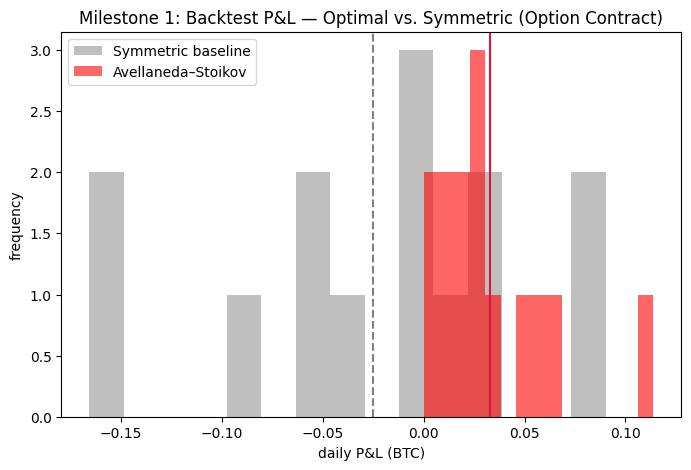

In [12]:
import matplotlib.pyplot as plt

opt_daily = opt.copy()
opt_daily['day'] = (opt_daily['t'] // 86400).astype(int)
opt_pnl = opt_daily.groupby('day')['pnl'].last().diff().dropna()

base_daily = base.copy()
base_daily['day'] = (base_daily['t'] // 86400).astype(int)
base_pnl = base_daily.groupby('day')['pnl'].last().diff().dropna()

plt.figure(figsize=(8,5))
plt.hist(base_pnl, bins=15, alpha=0.5, label='Symmetric baseline', color='gray')
plt.hist(opt_pnl, bins=15, alpha=0.6, label='Avellaneda–Stoikov', color='red')
plt.axvline(base_pnl.mean(), color='gray', linestyle='--')
plt.axvline(opt_pnl.mean(), color='crimson')
plt.xlabel('daily P&L (BTC)')
plt.ylabel('frequency')
plt.title('Milestone 1: Backtest P&L — Optimal vs. Symmetric (Option Contract)')
plt.legend()
plt.savefig('pnl_histogram.png', dpi=150)
plt.show()


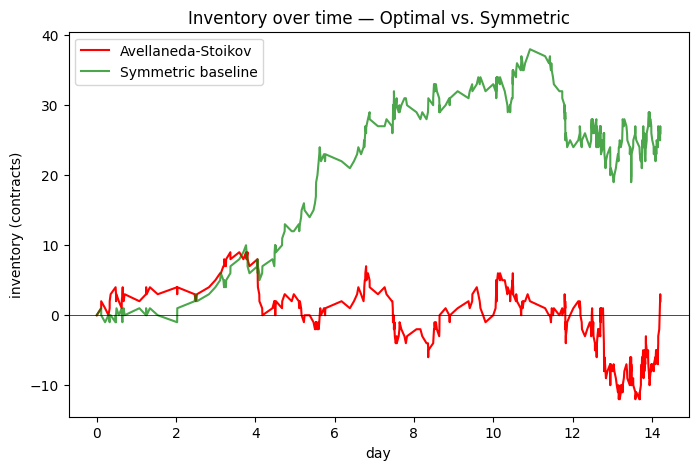

In [10]:
plt.figure(figsize=(8,5))
plt.plot(opt['t']/86400, opt['inventory'], label='Avellaneda-Stoikov', color='red')
plt.plot(base['t']/86400, base['inventory'], label='Symmetric baseline', color='green', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('day')
plt.ylabel('inventory (contracts)')
plt.title('Inventory over time — Optimal vs. Symmetric')
plt.legend()
plt.savefig('inventory_timeseries.png', dpi=150)
plt.show()